<center>
<h1>ISAT341-Data Science and Machine Learning
    </center>
    <center>
    <h2 style = "color:blue"> Lab 3- Multiple Linear Regression with Imported Data</h2>
</center>
    <img src="Images/machine-learning.jpg" width=200; height=200>
    <center>
    <h2>Multiple Linear Regression (The Diabetes Dataset)
    </center>

<center>
    <h3>By Joshua Brewington</h3>
    </center>
<u>Objectives</u>

- Create and use Machine Learning Models with SciKit Learn 
- Learn more advanced NumPy (Numerical Python) features  
- Learn how import data for remote website (UCI Datasets)  
- Learn how to import and use SciKit Learn built-in datasets (Diabetes) 
- Perform Multiple Regression Analysis with SciKit Learn 
- Train-Test Split of data with SciKit Learn 
- Create Predictive Models 
- Perform 3D Plotting with MatPlotLib 
- Preform Model Evaluation 
    - Model Score and Accuracy

<u>Introduction</u>

Last lab we went from simple linear regression modeling with onr predictor to a linear regression anaylsis with two or more predictors. Last lab fitted a 2D surface to a dataset generated by SciKit Learn dataset generator. We used an ordinary least squares regression function, which solves mathematical problems of the form

<h2 style="text-align:center; color:indigo;">
$\frac{\min}{w}\;\left\| {y - Xw} \right\|$
</h2>

where w is the set of coefficients. The number of coefficients depends on the number of dimensions in the data, N(coeff) =MD − 1, where M >1 and is an integer.

When dealing with multiple regression, it is more efficient to use matrices due to the number of predictors. In the future, we will use more multiple regression formulas in matrix form.

Our <u>predictor</u> after the regression fit was in the form of

<p style="text-align:center; color:blue";> y = ω<sub>1</sub>x<sub>1</sub> + ω<sub>2</sub>x<sub>2</sub>... ω<sub>n</sub>x<sub>n</sub> + ω<sub>0</sub></p>

where the wi  coefficients were ‘learned’ from the analysis. The LinearRegression method of ScitKit Learn was used to train the model with data and provide a best fit, make predictions, and tested the validity of the model. In this lab, we will perform a similar methodology extracting data from an external source.

| Dataset characteristics |  |
| :-------------------- |:--- |
| number of instances:    | 442 |
| number of attributes:   | First 10 columns are numeric predictive values |
| Target: | Column 11 is a quantitative measure of disease progression 1 year after baseline |
| Attributes | S1 |
|  | Age |
|  | Sex |
|  | BMI |
|  | Average Blood Pressure |
|  | S2 |
|  | S3 |
|  | S4 |
|  | S5 |
|  | S6 |

This chart displays the first 10 features.

## Importing packages

In [1]:
%matplotlib inline
import numpy as np

## Part 1: Building a Model using ScitKit-Learn

Let's build a model with an imported dataset.

In [2]:
#Load the diabetes dataset
from sklearn import datasets, linear_model
diabetes = datasets.load_diabetes()

# the diabetes dataset is stored as a python dictionary (key:value pairs) with two keys 'target' and 'data'
# the value of the 'target' key is an 442 x 1 array and the value of the 'data' key is a 442 x 10 array

# store the feature matric (X) and response vector (y)
X=diabetes.data
y=diabetes.target
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


### Displaying the shapes

In [3]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


### "Observations", loads in data

In [4]:
# examine the first 5 rows of the feature matrix (note: we are creating and including the feature names here)
import pandas as pd
pd.DataFrame(X, columns=['Age','Sex','BMI','BP','s1','s2','s3','s4','s5','s6']).tail()

,Age,Sex,BMI,BP,s1,s2,s3,s4,s5,s6
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930
441,-0.045472,-0.044642,-0.073030,-0.081414,0.083740,0.027809,0.173816,-0.039493,-0.004220,0.003064


## Correlation

Below is a chart of the significant correlations between the features.

In [5]:
# examine correlation of features
df=pd.DataFrame(X, columns=['Age','Sex','BMI','BP','s1','s2','s3','s4','s5','s6'])
df.corr()

,Age,Sex,BMI,BP,s1,s2,s3,s4,s5,s6
Age,1.000000,0.173737,0.185085,0.335427,0.260061,0.219243,-0.075181,0.203841,0.270777,0.301731
Sex,0.173737,1.000000,0.088161,0.241013,0.035277,0.142637,-0.379090,0.332115,0.149918,0.208133
BMI,0.185085,0.088161,1.000000,0.395415,0.249777,0.261170,-0.366811,0.413807,0.446159,0.388680
BP,0.335427,0.241013,0.395415,1.000000,0.242470,0.185558,-0.178761,0.257653,0.393478,0.390429
s1,0.260061,0.035277,0.249777,0.242470,1.000000,0.896663,0.051519,0.542207,0.515501,0.325717
s2,0.219243,0.142637,0.261170,0.185558,0.896663,1.000000,-0.196455,0.659817,0.318353,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178761,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257653,0.542207,0.659817,-0.738493,1.000000,0.617857,0.417212
s5,0.270777,0.149918,0.446159,0.393478,0.515501,0.318353,-0.398577,0.617857,1.000000,0.464670
s6,0.301731,0.208133,0.388680,0.390429,0.325717,0.290600,-0.273697,0.417212,0.464670,1.000000


## Building a model with two features BMI and BP

In [6]:
# use only two features BMI and BP
features = (2,3)
X=X[:,features]

## Splitting the dataset into training and testing sets

In [7]:
# from sklearn.model_selection to import train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=0)

The sets were split via 75%-25% in training and testing datasets respectively. This was done when the 'test_size' variable was set to 0.25.

In [8]:
# examine the training and test data
print('X_train.shape: {}'.format(X_train.shape))
print('y_train.shape: {}'.format(y_train.shape))

print('X_test.shape: {}'.format(X_test.shape))
print('y_test.shape: {}'.format(y_test.shape))

X_train.shape: (331, 2)
y_train.shape: (331,)
X_test.shape: (111, 2)
y_test.shape: (111,)


The datasets were examined to view their shapes in their respective rows and columns.

array([[<AxesSubplot:xlabel='BMI', ylabel='BMI'>,
        <AxesSubplot:xlabel='BP', ylabel='BMI'>],
       [<AxesSubplot:xlabel='BMI', ylabel='BP'>,
        <AxesSubplot:xlabel='BP', ylabel='BP'>]], dtype=object)

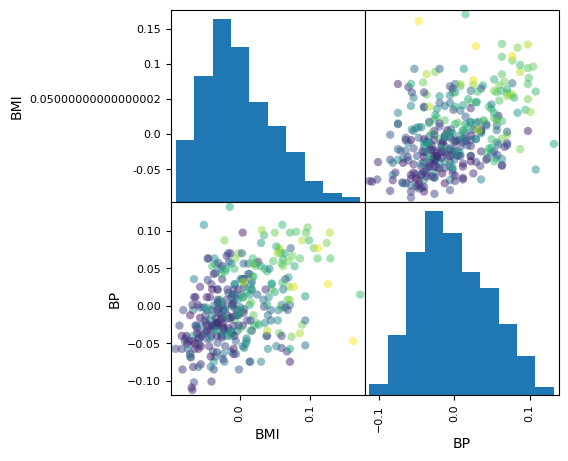

In [9]:
# create a pandas dataframe for plotting our data
diabetes_dataframe = pd.DataFrame(X_train, columns=['BMI','BP'])

pd.plotting.scatter_matrix(diabetes_dataframe, c=y_train, figsize=(5,5), marker='o', hist_kwds={'bins':10})

We created a scatter matrix for our generated data.

## Creating a Predictive Model

<h3 style = "color:green">Time to build a model using the LinearRegression() method and calling the fit function.</h3>

In [10]:
# instanitate the model with default parameters (i.e. create an instance of the model).
# this is ordinary least squares regression OLS
regr = linear_model.LinearRegression()

#training the model (i.e. fit the model with training data)
regr.fit(X_train, y_train)

#printing the coefficients
print(regr.coef_)

[855.51017633 383.24090075]


<h2 u>Model Evaluation: Let's make a Prediction and score the model's accuracy.

**Part 2: Using our Model to Make Predictions**

<h3 style="color:green">Making Predictions:

Our model has been trained and now we can use it to make predictions on new data. We may not know the correct outcomes (y-values). To make a prediction, the new observation must have the same features as the training observations, both in number and meaning.

In [11]:
# Predicting y-value based on the training. We input a normalized list of BMI and BP data [BMI, BP]
X_new = np.array([0.019662, 0.059744])
# using patient number 437
# reshape the array so numpy can use it
X_new = np.reshape(X_new, (1,-1))
print('X_new shape: {}'.format(X_new.shape))

X_new shape: (1, 2)


We must call the predict method of the regr object to make a prediction:

In [12]:
pred = regr.predict(X_new)[0]
print('Prediction from model is: {0:.2f}'.format(pred))
print('True value from dataset is: {0:.2f}'.format(y[437]))

Prediction from model is: 193.10
True value from dataset is: 178.00


In [13]:
print("The model's test set accuracy is {0:.2f}%".format(100*regr.score(X_test,y_test)))

The model's test set accuracy is 24.62%


## The Multivariate Model Equation

In [14]:
# get the regression coefficients( note: two features, so two coefficients) and the intercept
# printing the coefficients
coef0=regr.coef_[0]
coef1=regr.coef_[1]
intercept=regr.intercept_
print('The coefficient of the feature BMI is {}'.format(coef0))
print('The coefficient of the feature BP is {}'.format(coef1))
print('The intercept has the value of {}'.format(intercept))

The coefficient of the feature BMI is 855.5101763296332
The coefficient of the feature BP is 383.2409007495853
The intercept has the value of 153.3821238179241


In the cell above, we extracted the coefficients of the features.

**Build the model equation and test it for the values indicated in the document**

The model equationn is:

> <h3 style ="color:orange">y=855.52*BMI+383.24*BP+153.38
    
where y is a quantitative measure of disease (diabetes) progression one year after baseline
    
<h3>Use our model equation with data to predict disease's progression

In [15]:
# Use same values from above for patient 437
BMI, BP = 0.019662, 0.059744
y=855.52*BMI + 383.24*BP + 153.38
print('Prediction from the model equation is: {0:.2f}'.format(y))

Prediction from the model equation is: 193.10


<h2 u>Creating 3D Plots with MatPlotLib

### Part 3: Plotting Our Model in 3D

**Plot the training and testing data on the fitted surface**

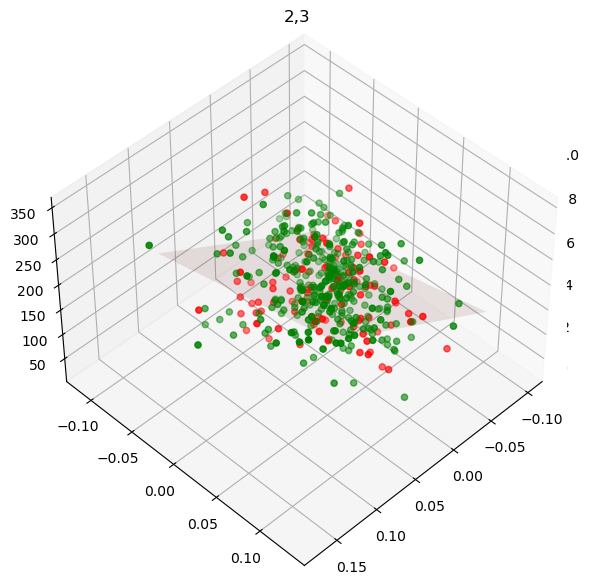

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# define an inline function (using lambda) with coefficient variables
# returned from the regression analysis
coef=regr.coef_
intercept=regr.intercept_
line=lambda x1, x2: coef[0]*x1 + coef[1]*x2 + intercept

# plotting
fig = plt.figure(figsize=(7,7))
grid_x1, grid_x2 = np.mgrid[-.1:.1:10j,-.1:.1:10j]
ax = fig.add_subplot(111,projection='3d',auto_add_to_figure=False)
ax = plt.axes(projection='3d')
ax.scatter(X_train[:,0],X_train[:,1], y_train, color='green')
ax.scatter(X_test[:,0],X_test[:,1], y_test, color='red')
ax.plot_surface(grid_x1, grid_x2, line(grid_x1, grid_x2), alpha=0.1, color='red')
plt.title("2,3")
ax.view_init (45,45) 

plt.show()
#fig.savefig('MLR_Lab_3.pdf')

<h2 u>Comments on the result</h2>

For this orientation, the features (2,3) had a test accuracy of 24.62%. The features 2, 3 were BMI and BP. For the 437th iteration of X, the predicted value for this was 193.10 and the actual value was 178.00. There was a significant drop off in the two values. Above depicts the plot involving all the different data points from our datasets. The scatter plot displayed the plane of best fit involving the multivariate function.